In [1]:
from sklearn.preprocessing import StandardScaler
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
import scipy
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy import linalg
from matplotlib.patches import Rectangle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


plot_path = '/home/u/u241308/figures/'

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [3]:
#correlation time period
time_min = 1965
time_max = 1995

In [4]:
#select North Atlantic area
lon_min_na = -80
lon_max_na = 20#30
lat_min_na = 30#20
lat_max_na = 80

In [5]:
#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

# Select lead years

In [6]:
lead_year = 1

In [7]:
#1-13 for Dec-Nov first lead year, 13-25 for Dec-Nov second lead year
if lead_year == 1:
    lead_min = 1 #to start in December, first lead year
    lead_max = 13 #To end in November, first lead year
if lead_year == 2:
    lead_min = 13 #to start in December, first lead year
    lead_max = 25 #To end in November, first lead year

## Get data

### Hybrid ML

In [8]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/mpiesm-1.2.01p7-levante/proccessed_output/ua/'
    file = 'ua_%i_r1-16i2p3-LR_26_months_360x180.nc' %(y_id)
    with xr.open_dataset(path+file) as ua_ML:
        ua_ML = ua_ML.ua.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(ua_ML)

#concatenate along time dimension
ua_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
ua_ML['lon'] = np.where(ua_ML.lon > 180,ua_ML.lon-360,ua_ML.lon)
ind_sort = np.argsort(ua_ML.lon)
ua_ML = ua_ML[:,:,:,ind_sort.values]

#select vertical levels
ua_850_ML = ua_ML[:,ua_ML.plev==85000]
ua_700_ML = ua_ML[:,ua_ML.plev==70000]

#change 'plev' dimension name to 'sfc'
ua_850_ML = ua_850_ML.rename({"plev": "sfc"})
ua_700_ML = ua_700_ML.rename({"plev": "sfc"})

#give different coordinates for each ensemble member in sfc:
ua_850_ML = ua_850_ML.assign_coords(sfc=np.arange(1, 17))
ua_700_ML = ua_700_ML.assign_coords(sfc=np.arange(1, 17))

#select lon lat
ua_850_ML = ua_850_ML.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
ua_700_ML = ua_700_ML.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [9]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/mpiesm-1.2.01p7-levante/proccessed_output/va/'
    file = 'va_%i_r1-16i2p3-LR_26_months_360x180.nc' %(y_id)
    with xr.open_dataset(path+file) as va_ML:
        va_ML = va_ML.va.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(va_ML)

#concatenate along time dimension
va_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
va_ML['lon'] = np.where(va_ML.lon > 180,va_ML.lon-360,va_ML.lon)
ind_sort = np.argsort(va_ML.lon)
va_ML = va_ML[:,:,:,ind_sort.values]

#select vertical levels
va_850_ML = va_ML[:,va_ML.plev==85000]
va_700_ML = va_ML[:,va_ML.plev==70000]

#change 'plev' dimension name to 'sfc'
va_850_ML = va_850_ML.rename({"plev": "sfc"})
va_700_ML = va_700_ML.rename({"plev": "sfc"})

#give different coordinates for each ensemble member in sfc:
va_850_ML = va_850_ML.assign_coords(sfc=np.arange(1, 17))
va_700_ML = va_700_ML.assign_coords(sfc=np.arange(1, 17))

#select lon lat
va_850_ML = va_850_ML.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
va_700_ML = va_700_ML.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [10]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/mpiesm-1.2.01p7-levante/proccessed_output/ta/'
    file = 'ta_%i_r1-16i2p3-LR_26_months_360x180.nc' %(y_id)
    with xr.open_dataset(path+file) as ta_ML:
        ta_ML = ta_ML.ta.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(ta_ML)

#concatenate along time dimension
ta_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
ta_ML['lon'] = np.where(ta_ML.lon > 180,ta_ML.lon-360,ta_ML.lon)
ind_sort = np.argsort(ta_ML.lon)
ta_ML = ta_ML[:,:,:,ind_sort.values]

#select vertical levels
ta_850_ML = ta_ML.sel(plev=85000, drop=True)
ta_700_ML = ta_ML.sel(plev=70000, drop=True)

#change 'depth' dimension name to 'sfc'
ta_850_ML = ta_850_ML.rename({"plev": "sfc"})
ta_700_ML = ta_700_ML.rename({"plev": "sfc"})

#give different coordinates for each ensemble member in sfc:
ta_850_ML = ta_850_ML.assign_coords(sfc=np.arange(1, 17))
ta_700_ML = ta_700_ML.assign_coords(sfc=np.arange(1, 17))

#select lon lat
ta_850_ML = ta_850_ML.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
ta_700_ML = ta_700_ML.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### Standard

In [11]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/ua_benchmark/processed/'
    file = 'ua_%i_r1-16i2p2-LR_3_years_360x180.nc' %(y_id)
    with xr.open_dataset(path+file) as ua_MPI:
        ua_MPI = ua_MPI.ua.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(ua_MPI)

#concatenate along time dimension
ua_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
ua_MPI['lon'] = np.where(ua_MPI.lon > 180,ua_MPI.lon-360,ua_MPI.lon)
ind_sort = np.argsort(ua_MPI.lon)
ua_MPI = ua_MPI[:,:,:,ind_sort.values]

#select vertical levels
ua_850_MPI = ua_MPI[:,ua_MPI.plev==85000]
ua_700_MPI = ua_MPI[:,ua_MPI.plev==70000]

#change 'depth' dimension name to 'sfc', so the dimension name matches with ua (only for ML, not for MPI)
ua_850_MPI = ua_850_MPI.rename({"plev": "sfc"})
ua_700_MPI = ua_700_MPI.rename({"plev": "sfc"})

#give different coordinates for each ensemble member in sfc:
ua_850_MPI = ua_850_MPI.assign_coords(sfc=np.arange(1, 17))
ua_700_MPI = ua_700_MPI.assign_coords(sfc=np.arange(1, 17))

#select lon lat
ua_850_MPI = ua_850_MPI.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
ua_700_MPI = ua_700_MPI.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [12]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/va_benchmark/processed/'
    file = 'va_%i_r1-16i2p2-LR_3_years_360x180.nc' %(y_id)
    with xr.open_dataset(path+file) as va_MPI:
        va_MPI = va_MPI.va.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(va_MPI)

#concatenate along time dimension
va_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
va_MPI['lon'] = np.where(va_MPI.lon > 180,va_MPI.lon-360,va_MPI.lon)
ind_sort = np.argsort(va_MPI.lon)
va_MPI = va_MPI[:,:,:,ind_sort.values]

#select vertical levels
va_850_MPI = va_MPI[:,va_MPI.plev==85000]
va_700_MPI = va_MPI[:,va_MPI.plev==70000]

#change 'depth' dimension name to 'sfc', so the dimension name matches with va (only for ML, not for MPI)
va_850_MPI = va_850_MPI.rename({"plev": "sfc"})
va_700_MPI = va_700_MPI.rename({"plev": "sfc"})

#give different coordinates for each ensemble member in sfc:
va_850_MPI = va_850_MPI.assign_coords(sfc=np.arange(1, 17))
va_700_MPI = va_700_MPI.assign_coords(sfc=np.arange(1, 17))

#select lon lat
va_850_MPI = va_850_MPI.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
va_700_MPI = va_700_MPI.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [13]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/ta_benchmark/processed/'
    file = 'ta_%i_r1-16i2p2-LR_3_years_360x180.nc' %(y_id)
    with xr.open_dataset(path+file) as ta_MPI:
        ta_MPI = ta_MPI.ta.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(ta_MPI)

#concatenate along time dimension
ta_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
ta_MPI['lon'] = np.where(ta_MPI.lon > 180,ta_MPI.lon-360,ta_MPI.lon)
ind_sort = np.argsort(ta_MPI.lon)
ta_MPI = ta_MPI[:,:,:,ind_sort.values]

#select vertical levels
ta_850_MPI = ta_MPI[:,ta_MPI.plev==85000]
ta_700_MPI = ta_MPI[:,ta_MPI.plev==70000]

#change 'depth' dimension name to 'sfc', so the dimension name matches with ta (only for ML, not for MPI)
ta_850_MPI = ta_850_MPI.rename({"plev": "sfc"})
ta_700_MPI = ta_700_MPI.rename({"plev": "sfc"})

#give different coordinates for each ensemble member in sfc:
ta_850_MPI = ta_850_MPI.assign_coords(sfc=np.arange(1, 17))
ta_700_MPI = ta_700_MPI.assign_coords(sfc=np.arange(1, 17))

#select lon lat
ta_850_MPI = ta_850_MPI.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
ta_700_MPI = ta_700_MPI.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### ERA5

In [14]:
# Load, slice, and collect datasets
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_ua_monthly_850-700hPa_1940-2023_360x180.nc'
with xr.open_dataset(path+file) as ua_era:
    ua_era = ua_era.var131

#select period
ua_era = ua_era[(ua_era.time.dt.year>=time_min)&(ua_era.time.dt.year<=time_max)]

#new longitudes
ua_era['lon'] = np.where(ua_era.lon > 180,ua_era.lon-360,ua_era.lon)
ind_sort = np.argsort(ua_era.lon)
ua_era = ua_era[:,:,:,ind_sort.values]

#homogenize to MPI and ML
ua_era = ua_era.sel(time=slice(ua_MPI.time[0].time, ua_MPI.time[-1].time))

#select vertical levels
ua_850_era = ua_era.sel(plev=85000, drop=True)
ua_700_era = ua_era.sel(plev=70000, drop=True)

#select lon lat
ua_850_era = ua_850_era.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
ua_700_era = ua_700_era.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))


In [15]:
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_va_monthly_850-700hPa_1940-2023_360x180.nc'
with xr.open_dataset(path+file) as va_era:
    va_era = va_era.var132

#select period
va_era = va_era[(va_era.time.dt.year>=time_min)&(va_era.time.dt.year<=time_max)]

#new longitudes
va_era['lon'] = np.where(va_era.lon > 180,va_era.lon-360,va_era.lon)
ind_sort = np.argsort(va_era.lon)
va_era = va_era[:,:,:,ind_sort.values]

#homogenize to MPI and ML
va_era = va_era.sel(time=slice(va_era.time[0].time, va_era.time[-1].time))

#select vertical levels
va_850_era = va_era.sel(plev=85000, drop=True)
va_700_era = va_era.sel(plev=70000, drop=True)

#select lon lat
va_850_era = va_850_era.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
va_700_era = va_700_era.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

In [16]:
# Load, slice, and collect datasets
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_ta_monthly_850-700hPa_1940-2023_360x180.nc' 
with xr.open_dataset(path+file) as ta_era:
    ta_era = ta_era.var130

#select period
ta_era = ta_era[(ta_era.time.dt.year>=time_min)&(ta_era.time.dt.year<=time_max)]

#new longitudes
ta_era['lon'] = np.where(ta_era.lon > 180,ta_era.lon-360,ta_era.lon)
ind_sort = np.argsort(ta_era.lon)
ta_era = ta_era[:,:,:,ind_sort.values]

#homogenize to MPI and ML
ta_era = ta_era.sel(time=slice(ta_era.time[0].time, ta_era.time[-1].time))

#select vertical levels
ta_850_era = ta_era.sel(plev=85000, drop=True)
ta_700_era = ta_era.sel(plev=70000, drop=True)

#select lon lat
ta_850_era = ta_850_era.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))
ta_700_era = ta_700_era.sel(lon=slice(lon_min_na, lon_max_na),lat=slice(lat_min_na, lat_max_na))

## Compute eady growth rate via hypsometric equation (we do not have geopotential height)

In [17]:
#layer thickness
Rd = 287.0       # J kg^-1 K^-1
g = 9.80665     # m s^-2

Tbar = 0.5 * (ta_850_ML + ta_700_ML)
dz_ML = (Rd / g) * Tbar * np.log(85000 / 70000)

Tbar = 0.5 * (ta_850_MPI + ta_700_MPI)
dz_MPI = (Rd / g) * Tbar * np.log(85000 / 70000)

Tbar = 0.5 * (ta_850_era + ta_700_era)
dz_era = (Rd / g) * Tbar * np.log(85000 / 70000)


In [18]:
#vertical wind shear
du_ML = ua_700_ML - ua_850_ML
dv_ML = va_700_ML - va_850_ML
dV_dz_ML = np.sqrt(du_ML**2 + dv_ML**2) / dz_ML

du_MPI = ua_700_MPI - ua_850_MPI
dv_MPI = va_700_MPI - va_850_MPI
dV_dz_MPI = np.sqrt(du_MPI**2 + dv_MPI**2) / dz_MPI

du_era = ua_700_era - ua_850_era
dv_era = va_700_era - va_850_era
dV_dz_era = np.sqrt(du_era**2 + dv_era**2) / dz_era

In [19]:
#statis stability

#potential temperature
p0 = 100000.0
kappa = 0.286

theta_850_ML = ta_850_ML * (p0 / 85000)**kappa
theta_700_ML = ta_700_ML * (p0 / 70000)**kappa

theta_850_MPI = ta_850_MPI * (p0 / 85000)**kappa
theta_700_MPI = ta_700_MPI * (p0 / 70000)**kappa

theta_850_era = ta_850_era * (p0 / 85000)**kappa
theta_700_era = ta_700_era * (p0 / 70000)**kappa

#vertical gradient
dtheta_dz_ML = (theta_700_ML - theta_850_ML) / dz_ML
theta_bar_ML = 0.5 * (theta_700_ML + theta_850_ML)
N_ML = np.sqrt((g / theta_bar_ML) * dtheta_dz_ML)

dtheta_dz_MPI = (theta_700_MPI - theta_850_MPI) / dz_MPI
theta_bar_MPI = 0.5 * (theta_700_MPI + theta_850_MPI)
N_MPI = np.sqrt((g / theta_bar_MPI) * dtheta_dz_MPI)

dtheta_dz_era = (theta_700_era - theta_850_era) / dz_era
theta_bar_era = 0.5 * (theta_700_era + theta_850_era)
N_era = np.sqrt((g / theta_bar_era) * dtheta_dz_era)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/computation.py:760: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [20]:
#coriolis
Omega = 7.2921159e-5
f = 2 * Omega * np.sin(np.deg2rad(ua_ML.lat))

In [21]:
# Eady growth rate
sigma_ML = 0.31 * np.abs(f) * dV_dz_ML / N_ML
sigma_MPI = 0.31 * np.abs(f) * dV_dz_MPI / N_MPI
sigma_era = 0.31 * np.abs(f) * dV_dz_era / N_era

# SST

### Hybrid ML

In [22]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_ML_NA/anomaly/'
    file = 'sst_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_ML:
        sst_ML = sst_ML.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_ML)

#concatenate along time dimension
sst_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
sst_ML['lon'] = np.where(sst_ML.lon > 180,sst_ML.lon-360,sst_ML.lon)
ind_sort = np.argsort(sst_ML.lon)
sst_ML = sst_ML[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_ML = sst_ML.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_ML = sst_ML.assign_coords(sfc=np.arange(1, 17))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### Standard

In [23]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_benchmark/anomaly/'
    file = 'sst_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_MPI:
        sst_MPI = sst_MPI.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_MPI)

#concatenate along time dimension
sst_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
sst_MPI['lon'] = np.where(sst_MPI.lon > 180,sst_MPI.lon-360,sst_MPI.lon)
ind_sort = np.argsort(sst_MPI.lon)
sst_MPI = sst_MPI[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_MPI = sst_MPI.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_MPI = sst_MPI.assign_coords(sfc=np.arange(1, 17))


/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### ERA5

In [24]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_sst_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
sst_era = xr.open_dataset(path+file).sst

#select period
sst_era = sst_era[(sst_era.time.dt.year>=time_min)&(sst_era.time.dt.year<=time_max)]

#new longitudes
sst_era['lon'] = np.where(sst_era.lon > 180,sst_era.lon-360,sst_era.lon)
ind_sort = np.argsort(sst_era.lon)
sst_era = sst_era[:,:,ind_sort.values]

#homogenize to MPI and ML
sst_era = sst_era.sel(time=slice(sst_MPI.time[0].time, sst_MPI.time[-1].time))

# Z500

### Hybrid ML

In [25]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_ML_NA/anomaly/'
    file = 'z500_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_ML:
        z500_ML = z500_ML.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_ML)

#concatenate along time dimension
z500_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_ML['lon'] = np.where(z500_ML.lon > 180,z500_ML.lon-360,z500_ML.lon)
ind_sort = np.argsort(z500_ML.lon)
z500_ML = z500_ML[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
z500_ML = z500_ML.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_ML = z500_ML.assign_coords(sfc=np.arange(1, 17))

##ensemble mean
#z500_ML = z500_ML.mean(dim='sfc')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### Standard

In [26]:
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_benchmark/anomaly/'
    file = 'z500_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_MPI:
        z500_MPI = z500_MPI.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_MPI)

#concatenate along time dimension
z500_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_MPI['lon'] = np.where(z500_MPI.lon > 180,z500_MPI.lon-360,z500_MPI.lon)
ind_sort = np.argsort(z500_MPI.lon)
z500_MPI = z500_MPI[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
z500_MPI = z500_MPI.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_MPI = z500_MPI.assign_coords(sfc=np.arange(1, 17))

##ensemble mean
#z500_MPI = z500_MPI.mean(dim='sfc')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### ERA5

In [27]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_z500_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
z500_era = xr.open_dataset(path+file).z

#select period
z500_era = z500_era[(z500_era.time.dt.year>=time_min)&(z500_era.time.dt.year<=time_max)]

#new longitudes
z500_era['lon'] = np.where(z500_era.lon > 180,z500_era.lon-360,z500_era.lon)
ind_sort = np.argsort(z500_era.lon)
z500_era = z500_era[:,:,ind_sort.values]

#homogenize to MPI and ML
z500_era = z500_era.sel(time=slice(z500_MPI.time[0].time, z500_MPI.time[-1].time))

# Seasonal mean

In [28]:
def compute_seasonal_means(da):
    time = da['time'].to_index()

    season_year = time.year + (time.month == 12)
    season = da['time'].dt.season.values

    season_id = [f"{y}-{s}" for y, s in zip(season_year, season)]

    da = da.assign_coords(
        season=('time', season),
        season_year=('time', season_year),
        season_id=('time', season_id)
    )

    grouped = da.groupby('season_id').mean('time')

    season_ts = {}
    for sid in grouped['season_id'].values:
        year, s = sid.split('-')
        year = int(year)
        if s not in season_ts:
            season_ts[s] = []
        da_season = grouped.sel(season_id=sid).expand_dims({'season_year': [year]})
        season_ts[s].append(da_season)

    for season in season_ts:
        season_ts[season] = xr.concat(season_ts[season], dim='season_year')

    return season_ts

In [29]:
# Compute seasonal mean
sst_era_seasonal = compute_seasonal_means(sst_era)
sst_MPI_seasonal = compute_seasonal_means(sst_MPI)
sst_ML_seasonal = compute_seasonal_means(sst_ML)

z500_era_seasonal = compute_seasonal_means(z500_era)
z500_MPI_seasonal = compute_seasonal_means(z500_MPI)
z500_ML_seasonal = compute_seasonal_means(z500_ML)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spa

In [30]:
#Compute seasonal correlation
season_list = ['DJF','MAM','JJA','SON']

sst_MPI_seasonal_std = {}
sst_ML_seasonal_std = {}
z500_MPI_seasonal_std = {}
z500_ML_seasonal_std = {}
for seas in season_list:
    #MPI
    sst_MPI_seasonal_std[seas] = sst_MPI_seasonal[seas].std(dim=('season_year','sfc'))
    z500_MPI_seasonal_std[seas] = z500_MPI_seasonal[seas].std(dim=('season_year','sfc'))
    #ML
    sst_ML_seasonal_std[seas] = sst_ML_seasonal[seas].std(dim=('season_year','sfc'))
    z500_ML_seasonal_std[seas] = z500_ML_seasonal[seas].std(dim=('season_year','sfc'))

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10

# Plot

In [31]:
#create a discrete colormaps
import matplotlib as mpl

#sst
cmap1 = plt.cm.viridis  # define the colormap
cmaplist = [cmap1(i) for i in range(cmap1.N)]
cmap1 = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap1.N)
bounds = np.linspace(0, 1.5, 7)
norm_sst = mpl.colors.BoundaryNorm(bounds, cmap1.N)

cmap2 = plt.cm.RdBu_r  # define the colormap
cmaplist = [cmap2(i) for i in range(cmap2.N)]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap2', cmaplist, cmap2.N)
bounds = np.linspace(-0.4, 0.4, 9)
norm_sst_diff = mpl.colors.BoundaryNorm(bounds, cmap2.N)

#z500
cmap1 = plt.cm.viridis  # define the colormap
cmaplist = [cmap1(i) for i in range(cmap1.N)]
cmap1 = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap1.N)
bounds = np.linspace(0, 70, 8)
norm_z500 = mpl.colors.BoundaryNorm(bounds, cmap1.N)

cmap2 = plt.cm.RdBu_r  # define the colormap
cmaplist = [cmap2(i) for i in range(cmap2.N)]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap2', cmaplist, cmap2.N)
bounds = np.linspace(-12, 12, 9)
norm_z500_diff = mpl.colors.BoundaryNorm(bounds, cmap2.N)


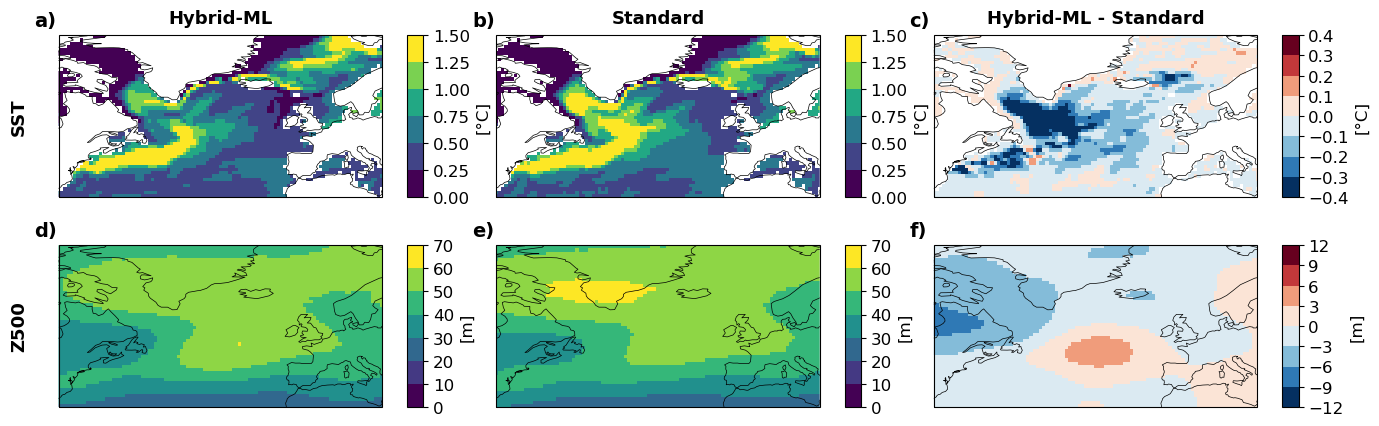

In [32]:
#Select season
seas = 'DJF'

#Plot
row = 2
column = 3

fig = plt.figure(figsize=(16,5))#(15,10))
plt.rcParams.update({'font.size': 12})
#plt.suptitle('SPG-ws correlation')

# SST
plot_data1 = sst_ML_seasonal_std[seas]
ax1 = plt.subplot(row,column,1, projection=ccrs.PlateCarree())
plt.pcolormesh(plot_data1.lon,plot_data1.lat,plot_data1,cmap=cmap1,norm=norm_sst)
plt.xlim([lon_min_na,lon_max_na])
plt.ylim([lat_min_na,lat_max_na])
ax1.coastlines(resolution='110m',lw=0.5,color='k'); ax1.set_facecolor('w')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(cax=cax)
cb.set_label(r'[°C]') 

plot_data2 = sst_MPI_seasonal_std[seas]
ax2 = plt.subplot(row,column,2, projection=ccrs.PlateCarree())
plt.pcolormesh(plot_data2.lon,plot_data2.lat,plot_data2,cmap=cmap1,norm=norm_sst)
plt.xlim([lon_min_na,lon_max_na])
plt.ylim([lat_min_na,lat_max_na])
ax2.coastlines(resolution='110m',lw=0.5,color='k'); ax2.set_facecolor('w')
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(cax=cax)
cb.set_label(r'[°C]') 

plot_data3 = plot_data1-plot_data2
ax3 = plt.subplot(row,column,3, projection=ccrs.PlateCarree())
plt.pcolormesh(plot_data3.lon,plot_data3.lat,plot_data3,cmap=cmap2,norm=norm_sst_diff)
plt.xlim([lon_min_na,lon_max_na])
plt.ylim([lat_min_na,lat_max_na])
ax3.coastlines(resolution='110m',lw=0.5,color='k'); ax3.set_facecolor('w')
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(cax=cax)
cb.set_label(r'[°C]') 
    

# Z500
plot_data1 = z500_ML_seasonal_std[seas]
ax4 = plt.subplot(row,column,4, projection=ccrs.PlateCarree())
plt.pcolormesh(plot_data1.lon,plot_data1.lat,plot_data1,cmap=cmap1,norm=norm_z500)
plt.xlim([lon_min_na,lon_max_na])
plt.ylim([lat_min_na,lat_max_na])
ax4.coastlines(resolution='110m',lw=0.5,color='k'); ax4.set_facecolor('w')
divider = make_axes_locatable(ax4)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(cax=cax)
cb.set_label(r'[m]') 

plot_data2 = z500_MPI_seasonal_std[seas]
ax5 = plt.subplot(row,column,5, projection=ccrs.PlateCarree())
plt.pcolormesh(plot_data2.lon,plot_data2.lat,plot_data2,cmap=cmap1,norm=norm_z500)
plt.xlim([lon_min_na,lon_max_na])
plt.ylim([lat_min_na,lat_max_na])
ax5.coastlines(resolution='110m',lw=0.5,color='k'); ax5.set_facecolor('w')
divider = make_axes_locatable(ax5)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(cax=cax)
cb.set_label(r'[m]') 

plot_data3 = plot_data1-plot_data2
ax6 = plt.subplot(row,column,6, projection=ccrs.PlateCarree())
plt.pcolormesh(plot_data3.lon,plot_data3.lat,plot_data3,cmap=cmap2,norm=norm_z500_diff)
plt.xlim([lon_min_na,lon_max_na])
plt.ylim([lat_min_na,lat_max_na])
ax6.coastlines(resolution='110m',lw=0.5,color='k'); ax6.set_facecolor('w')
divider = make_axes_locatable(ax6)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(cax=cax)
cb.set_label(r'[m]') 

rect_spg = Rectangle(
    (lon_min_spg, lat_min_spg),  # lower-left corner
    lon_max_spg - lon_min_spg,   # width
    lat_max_spg - lat_min_spg,   # height
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree()  # important!
)
#ax6.add_patch(rect_spg)

#Text
ax1.text(0.5, 1.05, 'Hybrid-ML', transform=ax1.transAxes,
            ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.text(0.5, 1.05, 'Standard', transform=ax2.transAxes,
            ha='center', va='bottom', fontsize=13, fontweight='bold')
ax3.text(0.5, 1.05, 'Hybrid-ML - Standard', transform=ax3.transAxes,
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.text(-0.15, 0.5, 'SST', transform=ax1.transAxes,
            va='center', rotation='vertical', fontsize=13, fontweight='bold')
ax4.text(-0.15, 0.5, 'Z500', transform=ax4.transAxes,
            va='center', rotation='vertical', fontsize=13, fontweight='bold')

# ================= Text =====================

x_pos = -0.075
y_pos = 1.15
ax1.text(
    x_pos, y_pos, 'a)',   # position (x,y)
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax2.text(
    x_pos, y_pos, 'b)',   # position (x,y)
    transform=ax2.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax3.text(
    x_pos, y_pos, 'c)',   # position (x,y)
    transform=ax3.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
ax4.text(
    x_pos, y_pos, 'd)',   # position (x,y)
    transform=ax4.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax5.text(
    x_pos, y_pos, 'e)',   # position (x,y)
    transform=ax5.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax6.text(
    x_pos, y_pos, 'f)',   # position (x,y)
    transform=ax6.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

plt.savefig(plot_path+'sst_z500_NA_DJF_std_%ileadyear_period_%i-%i'%(lead_year,time_min,time_max),bbox_inches="tight",dpi=100) 